# WESM Price Prediction, Bonus: LSTM (with Hyperparameter Tuning)

## Setup and Loading

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")

Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00


---

## I. Why LSTM?

The feedforward neural network treats each 5-minute interval as an independent input. It only knows about the past through the three lag features (GWAP_Lag_1, GWAP_Lag_12, GWAP_Lag_288) that were manually engineered. An LSTM is different: it processes the data as a sequence and learns temporal patterns directly from the raw data.

This makes the LSTM a possibly better solution. If it performs significantly better, this would mean that the temporal structure of GWAP contains more information than the three lags we chose. If it performs similarly or worse, it suggests the lag features were already capturing the most important temporal signal (or the data we have may be insufficient).

**Note:** Removing the lag features from the LSTM input was tested and performed worse, confirming that GWAP_Lag_1 carries genuine signal that the model benefits from even with sequential processing. This is consistent with the Linear Regression coefficient analysis where GWAP_Lag_1 had the largest coefficient by far.

---

## II. Feature Selection

The same 16 base features as the other notebooks are used. Refer to the Linear Regression notebook for the full feature justification table.

One difference from the other notebooks: the LSTM receives sequences of these features over a lookback window rather than a single row at a time. The optimal lookback length is determined through hyperparameter tuning in Section VII.

In [64]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Features: {len(FEATURE_COLS)}")

Features: 16


---

## III. Train / Validation / Test Split

Same chronological 60/20/20 split as the other notebooks. The sequence construction is applied separately to each split after splitting. This prevents a sequence window from spanning the boundary between splits, which would mix training and validation data within the same input sample. This is not quite the same as label leakage but still an undesirable contamination of the splits.


In [65]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  20721 rows | 2025-10-29 to 2026-01-08
Val   :   6907 rows | 2026-01-08 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


---

## IV. Feature and Target Scaling

**Features** are standardized the same way as the other notebooks: the scaler is fit only on training data, then applied to validation and test.

**Target (GWAP)** is also standardized using a separate scaler. This is important for LSTM (and NN) since we don't want to explode the gradient descent process. Predictions are converted back to ₱/MWh before evaluation, so the metrics remain comparable with the other notebooks.

In [66]:
# Feature scaler
feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLS])
X_val_scaled   = feature_scaler.transform(val_df[FEATURE_COLS])
X_test_scaled  = feature_scaler.transform(test_df[FEATURE_COLS])

# Target scaler
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]]).flatten()
y_val_scaled   = target_scaler.transform(val_df[[TARGET_COL]]).flatten()
y_test_scaled  = target_scaler.transform(test_df[[TARGET_COL]]).flatten()

# Raw targets for evaluation
y_train_raw = train_df[TARGET_COL].values
y_val_raw   = val_df[TARGET_COL].values
y_test_raw  = test_df[TARGET_COL].values

print(f"Scaled target - Train mean: {y_train_scaled.mean():.4f}, std: {y_train_scaled.std():.4f}")
print(f"Scaled target - Val   mean: {y_val_scaled.mean():.4f}, std: {y_val_scaled.std():.4f}")
print(f"Scaled target - Test  mean: {y_test_scaled.mean():.4f}, std: {y_test_scaled.std():.4f}")

Scaled target - Train mean: 0.0000, std: 1.0000
Scaled target - Val   mean: -0.2980, std: 0.8336
Scaled target - Test  mean: -0.1521, std: 0.5585


---

## V. Sequence Construction

LSTMs require input in the shape `(samples, timesteps, features)`. A sliding window of length `lookback` is used to build each sample: for each target value at time `t`, the input is the block of features from `t-lookback` to `t-1`. So if lookback = 24, the model sees the past 2 hours of data before making each prediction.

Since the lookback is a tunable hyperparameter, we defined the sequence builder as a function so we can use it for hypertuning.

In [67]:
def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

---

## VI. Tuning Framework

The `build_and_train` function below constructs, compiles, and trains an LSTM model for a given set of hyperparameters. It returns the trained model, training history, and wall-clock time. This is used by the tuning loop in Section VII.

The function supports the following tunable dimensions:

| Hyperparameter | What it controls | Values Tested |
|---|---|---|
| `lookback` | How many past timesteps the model sees | 12, 24, 48 |
| `lstm_units` | Number of neurons (hidden units) per LSTM layer | 32, 64, 128 |
| `num_layers` | How many LSTM layers are stacked | 1, 2 |
| `dropout` | Fraction of units randomly disabled during training | 0.1, 0.2, 0.3 |
| `learning_rate` | Step size for gradient descent | 0.001, 0.0005 |
| `batch_size` | Number of samples processed per training step | 128, 256 |

In [68]:
def build_and_train(lookback, lstm_units, num_layers, dropout, learning_rate, batch_size, verbose=0):

    # Build sequences for this lookback
    X_tr, y_tr = make_sequences(X_train_scaled, y_train_scaled, lookback)
    X_va, y_va = make_sequences(X_val_scaled,   y_val_scaled,   lookback)

    # Build model
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential()
    model.add(layers.Input(shape=(lookback, len(FEATURE_COLS))))

    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # only last LSTM returns single output
        model.add(layers.LSTM(lstm_units, return_sequences=return_seq))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse"
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    start = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stop],
        shuffle=False,
        verbose=verbose
    )
    elapsed = time.time() - start

    # Evaluate on validation set (in original scale)
    _, y_va_raw = make_sequences(X_val_scaled, y_val_raw, lookback)
    y_va_pred_scaled = model.predict(X_va, verbose=0).flatten()
    y_va_pred = target_scaler.inverse_transform(y_va_pred_scaled.reshape(-1, 1)).flatten()

    val_rmse = np.sqrt(mean_squared_error(y_va_raw, y_va_pred))
    val_mae  = mean_absolute_error(y_va_raw, y_va_pred)
    val_r2   = r2_score(y_va_raw, y_va_pred)

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = min(history.history["val_loss"])

    return {
        "model": model,
        "history": history,
        "lookback": lookback,
        "lstm_units": lstm_units,
        "num_layers": num_layers,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "val_r2": val_r2,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "elapsed": elapsed
    }

---

## VII. Hyperparameter Tuning

A structured manual search is used instead of a full grid search (which would be 3 x 3 x 2 x 3 x 2 x 2 = 216 combinations). The search is organized in three phases:

1. **Phase 1, Architecture search**: change lookback, LSTM units, and number of layers while keeping dropout=0.2, lr=0.001, batch_size=256.
2. **Phase 2, Regularization search**: take the best architecture from Phase 1, then change dropout and learning rate.
3. **Phase 3, Batch size**: take the best config so far, then test batch sizes.

This narrows the search to roughly 15 configurations, each taking about 30 seconds to 2 minutes to train.

In [ ]:
results = []

# Phase 1: Architecture (lookback x units x layers)
print("=" * 70)
print("PHASE 1: Architecture Search")
print("=" * 70)

phase1_configs = [
    # (lookback, units, layers)
    (12, 32, 1),
    (12, 64, 1),
    (12, 64, 2),
    (24, 32, 1),
    (24, 64, 1),
    (24, 64, 2),
    (24, 128, 1),
    (24, 128, 2),
    (48, 64, 1),
    (48, 64, 2),
    (48, 128, 1),
]

for i, (lb, units, nlayers) in enumerate(phase1_configs):
    tag = f"[{i+1}/{len(phase1_configs)}] lb={lb}, units={units}, layers={nlayers}"
    print(f"\n{tag}")

    r = build_and_train(
        lookback=lb, lstm_units=units, num_layers=nlayers,
        dropout=0.2, learning_rate=0.001, batch_size=256
    )
    results.append(r)

    print(f"  Val RMSE: {r['val_rmse']:.2f} | Val R²: {r['val_r2']:.4f} | "
          f"Epoch: {r['best_epoch']} | Time: {r['elapsed']:.0f}s")

# Find best Phase 1 config
phase1_best = min(results, key=lambda x: x["val_rmse"])
print(f"\n>>> Phase 1 Best: lb={phase1_best['lookback']}, units={phase1_best['lstm_units']}, "
      f"layers={phase1_best['num_layers']} | Val RMSE: {phase1_best['val_rmse']:.2f}, "
      f"R²: {phase1_best['val_r2']:.4f}")

PHASE 1: Architecture Search

[1/11] lb=12, units=32, layers=1
  Val RMSE: 1215.60 | Val R²: 0.7505 | Epoch: 55 | Time: 38s

[2/11] lb=12, units=64, layers=1
  Val RMSE: 1237.91 | Val R²: 0.7413 | Epoch: 28 | Time: 45s

[3/11] lb=12, units=64, layers=2
  Val RMSE: 1238.71 | Val R²: 0.7410 | Epoch: 42 | Time: 128s

[4/11] lb=24, units=32, layers=1
  Val RMSE: 1227.00 | Val R²: 0.7461 | Epoch: 53 | Time: 83s

[5/11] lb=24, units=64, layers=1
  Val RMSE: 1294.78 | Val R²: 0.7173 | Epoch: 20 | Time: 69s

[6/11] lb=24, units=64, layers=2
  Val RMSE: 1276.63 | Val R²: 0.7251 | Epoch: 18 | Time: 133s

[7/11] lb=24, units=128, layers=1
  Val RMSE: 1202.34 | Val R²: 0.7562 | Epoch: 18 | Time: 131s

[8/11] lb=24, units=128, layers=2
  Val RMSE: 1188.39 | Val R²: 0.7618 | Epoch: 25 | Time: 344s

[9/11] lb=48, units=64, layers=1
  Val RMSE: 1236.26 | Val R²: 0.7431 | Epoch: 24 | Time: 138s

[10/11] lb=48, units=64, layers=2
  Val RMSE: 1260.81 | Val R²: 0.7328 | Epoch: 40 | Time: 319s

[11/11] lb=

In [70]:
# Phase 2: Regularization (dropout x learning rate)
print("=" * 70)
print("PHASE 2: Regularization Search")
print("=" * 70)

best_lb     = phase1_best["lookback"]
best_units  = phase1_best["lstm_units"]
best_layers = phase1_best["num_layers"]

phase2_configs = [
    # (dropout, learning_rate)
    (0.1, 0.001),
    (0.1, 0.0005),
    (0.2, 0.0005),
    (0.3, 0.001),
    (0.3, 0.0005),
]

for i, (drop, lr) in enumerate(phase2_configs):
    tag = f"[{i+1}/{len(phase2_configs)}] dropout={drop}, lr={lr}"
    print(f"\n{tag}")

    r = build_and_train(
        lookback=best_lb, lstm_units=best_units, num_layers=best_layers,
        dropout=drop, learning_rate=lr, batch_size=256
    )
    results.append(r)

    print(f"  Val RMSE: {r['val_rmse']:.2f} | Val R²: {r['val_r2']:.4f} | "
          f"Epoch: {r['best_epoch']} | Time: {r['elapsed']:.0f}s")

# Find best so far
phase2_best = min(results, key=lambda x: x["val_rmse"])
print(f"\n>>> Phase 2 Best: lb={phase2_best['lookback']}, units={phase2_best['lstm_units']}, "
      f"layers={phase2_best['num_layers']}, drop={phase2_best['dropout']}, "
      f"lr={phase2_best['learning_rate']} | Val RMSE: {phase2_best['val_rmse']:.2f}, "
      f"R²: {phase2_best['val_r2']:.4f}")

PHASE 2: Regularization Search

[1/5] dropout=0.1, lr=0.001
  Val RMSE: 1271.21 | Val R²: 0.7275 | Epoch: 14 | Time: 212s

[2/5] dropout=0.1, lr=0.0005
  Val RMSE: 1219.08 | Val R²: 0.7493 | Epoch: 35 | Time: 536s

[3/5] dropout=0.2, lr=0.0005
  Val RMSE: 1279.07 | Val R²: 0.7241 | Epoch: 23 | Time: 398s

[4/5] dropout=0.3, lr=0.001
  Val RMSE: 1220.60 | Val R²: 0.7487 | Epoch: 23 | Time: 406s

[5/5] dropout=0.3, lr=0.0005
  Val RMSE: 1258.58 | Val R²: 0.7328 | Epoch: 31 | Time: 485s

>>> Phase 2 Best: lb=24, units=128, layers=2, drop=0.2, lr=0.001 | Val RMSE: 1188.39, R²: 0.7618


In [71]:
# Phase 3: Batch size
print("=" * 70)
print("PHASE 3: Batch Size Search")
print("=" * 70)

best_drop = phase2_best["dropout"]
best_lr   = phase2_best["learning_rate"]

for bs in [64, 128]:
    tag = f"batch_size={bs}"
    print(f"\n{tag}")

    r = build_and_train(
        lookback=best_lb, lstm_units=best_units, num_layers=best_layers,
        dropout=best_drop, learning_rate=best_lr, batch_size=bs
    )
    results.append(r)

    print(f"  Val RMSE: {r['val_rmse']:.2f} | Val R²: {r['val_r2']:.4f} | "
          f"Epoch: {r['best_epoch']} | Time: {r['elapsed']:.0f}s")

# Overall best
overall_best = min(results, key=lambda x: x["val_rmse"])
print(f"\n{'=' * 70}")
print(f"OVERALL BEST CONFIG:")
print(f"  Lookback      : {overall_best['lookback']}")
print(f"  LSTM units    : {overall_best['lstm_units']}")
print(f"  Num layers    : {overall_best['num_layers']}")
print(f"  Dropout       : {overall_best['dropout']}")
print(f"  Learning rate : {overall_best['learning_rate']}")
print(f"  Batch size    : {overall_best['batch_size']}")
print(f"  Val RMSE      : {overall_best['val_rmse']:.4f}")
print(f"  Val MAE       : {overall_best['val_mae']:.4f}")
print(f"  Val R²        : {overall_best['val_r2']:.4f}")
print(f"  Best epoch    : {overall_best['best_epoch']}")
print(f"{'=' * 70}")

PHASE 3: Batch Size Search

batch_size=64
  Val RMSE: 1196.73 | Val R²: 0.7585 | Epoch: 20 | Time: 442s

batch_size=128
  Val RMSE: 1213.48 | Val R²: 0.7516 | Epoch: 14 | Time: 281s

OVERALL BEST CONFIG:
  Lookback      : 24
  LSTM units    : 128
  Num layers    : 2
  Dropout       : 0.2
  Learning rate : 0.001
  Batch size    : 256
  Val RMSE      : 1188.3926
  Val MAE       : 686.9084
  Val R²        : 0.7618
  Best epoch    : 25


### Tuning Results Summary

In [72]:
summary = pd.DataFrame([{
    "Lookback": r["lookback"],
    "Units": r["lstm_units"],
    "Layers": r["num_layers"],
    "Dropout": r["dropout"],
    "LR": r["learning_rate"],
    "Batch": r["batch_size"],
    "Val RMSE": round(r["val_rmse"], 2),
    "Val MAE": round(r["val_mae"], 2),
    "Val R²": round(r["val_r2"], 4),
    "Epoch": r["best_epoch"],
    "Time (s)": round(r["elapsed"], 0)
} for r in results])

summary = summary.sort_values("Val RMSE").reset_index(drop=True)
summary.index = summary.index + 1  # 1-indexed ranking
summary.index.name = "Rank"

print(summary.to_string())

      Lookback  Units  Layers  Dropout      LR  Batch  Val RMSE  Val MAE  Val R²  Epoch  Time (s)
Rank                                                                                             
1           24    128       2      0.2  0.0010    256   1188.39   686.91  0.7618     25     344.0
2           24    128       2      0.2  0.0010     64   1196.73   674.59  0.7585     20     442.0
3           24    128       1      0.2  0.0010    256   1202.34   679.39  0.7562     18     131.0
4           24    128       2      0.2  0.0010    128   1213.48   713.13  0.7516     14     281.0
5           12     32       1      0.2  0.0010    256   1215.60   680.36  0.7505     55      38.0
6           24    128       2      0.1  0.0005    256   1219.08   702.81  0.7493     35     536.0
7           24    128       2      0.3  0.0010    256   1220.60   695.77  0.7487     23     406.0
8           24     32       1      0.2  0.0010    256   1227.00   694.82  0.7461     53      83.0
9           48    12

---

## VIII. Final Model (Best Configuration)

The best hyperparameters from the tuning search are used to retrain a final model. This model is then evaluated on the separated test set.

In [73]:
# Retrain best config
print("Retraining best configuration...")
print(f"  Lookback={overall_best['lookback']}, Units={overall_best['lstm_units']}, "
      f"Layers={overall_best['num_layers']}, Dropout={overall_best['dropout']}, "
      f"LR={overall_best['learning_rate']}, Batch={overall_best['batch_size']}")

BEST_LOOKBACK = overall_best["lookback"]

final_result = build_and_train(
    lookback=overall_best["lookback"],
    lstm_units=overall_best["lstm_units"],
    num_layers=overall_best["num_layers"],
    dropout=overall_best["dropout"],
    learning_rate=overall_best["learning_rate"],
    batch_size=overall_best["batch_size"],
    verbose=1
)

final_model = final_result["model"]
final_history = final_result["history"]

Retraining best configuration...
  Lookback=24, Units=128, Layers=2, Dropout=0.2, LR=0.001, Batch=256
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - loss: 0.5349 - val_loss: 0.3308
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - loss: 0.4011 - val_loss: 0.2798
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - loss: 0.3405 - val_loss: 0.2637
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.3077 - val_loss: 0.2657
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.2902 - val_loss: 0.2469
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - loss: 0.2806 - val_loss: 0.2301
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 0.2640 - val_loss: 0.2143
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - loss: 0.2582 - val_loss: 0.2215
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - loss: 0.2594 - val_loss: 0.1920
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.2571 - val_loss: 0.1931
Epoch 11/100
81/8

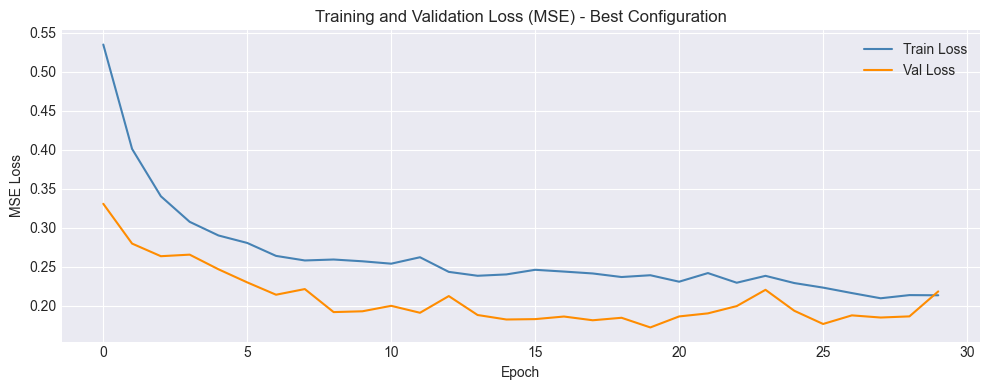

In [74]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(final_history.history["loss"],     label="Train Loss", color="steelblue")
ax.plot(final_history.history["val_loss"], label="Val Loss",   color="darkorange")
ax.set_title("Training and Validation Loss (MSE) - Best Configuration")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

---

## IX. Test Set Evaluation

The final model is evaluated on the test set using the same metrics as all other notebooks: RMSE, MAE, and R². Predictions are inverse-transformed from the scaled space back to ₱/MWh.

In [75]:
# Build test sequences with the best lookback
X_test_seq, y_test_seq_scaled = make_sequences(X_test_scaled, y_test_scaled, BEST_LOOKBACK)
_, y_test_seq_raw = make_sequences(X_test_scaled, y_test_raw, BEST_LOOKBACK)

# Predict and inverse-transform
y_test_pred_scaled = final_model.predict(X_test_seq).flatten()
y_test_pred = target_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_seq_raw, y_test_pred))
mae  = mean_absolute_error(y_test_seq_raw, y_test_pred)
r2   = r2_score(y_test_seq_raw, y_test_pred)

print(f"{'Metric':<8} | {'Value':>12}")
print("-" * 24)
print(f"{'RMSE':<8} | {rmse:>10.4f} ₱/MWh")
print(f"{'MAE':<8} | {mae:>10.4f} ₱/MWh")
print(f"{'R²':<8} | {r2:>12.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Metric   |        Value
------------------------
RMSE     |  1145.1461 ₱/MWh
MAE      |   733.6409 ₱/MWh
R²       |       0.5082


In [76]:
lr_test_rmse   = 934.4698
lr_test_mae    = 459.4758
lr_test_r2     = 0.6714

comparison = pd.DataFrame({
    "Model"    : ["Linear Regression", "Polynomial Ridge", "Poly Elastic Net", "LSTM (bonus)"],
    "Test RMSE": [lr_test_rmse, 972.1944, 930.0893, rmse],
    "Test MAE" : [lr_test_mae,  552.9226, 471.7096, mae],
    "Test R²"  : [lr_test_r2,   0.6444,   0.6745,   r2]
})

print(comparison.to_string(index=False))

            Model   Test RMSE   Test MAE  Test R²
Linear Regression  934.469800 459.475800 0.671400
 Polynomial Ridge  972.194400 552.922600 0.644400
 Poly Elastic Net  930.089300 471.709600 0.674500
     LSTM (bonus) 1145.146055 733.640863 0.508195


---

## X. Visualizations

### Actual vs. Predicted (Time Series)

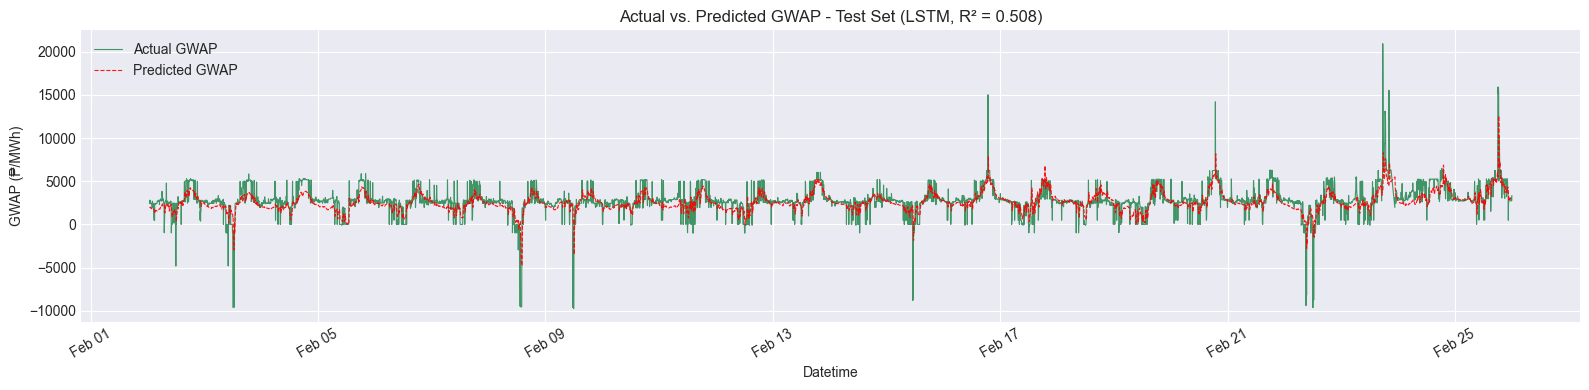

In [77]:
fig, ax = plt.subplots(figsize=(16, 4))

test_datetimes = test_df["datetime"].values[BEST_LOOKBACK:]

ax.plot(test_datetimes, y_test_seq_raw, color="seagreen",   linewidth=0.8, alpha=0.9, label="Actual GWAP")
ax.plot(test_datetimes, y_test_pred,    color="red",        linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
ax.set_title(f"Actual vs. Predicted GWAP - Test Set (LSTM, R² = {round(r2, 3)})")
ax.set_ylabel("GWAP (₱/MWh)")
ax.set_xlabel("Datetime")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Actual vs. Predicted, Scatter Plot

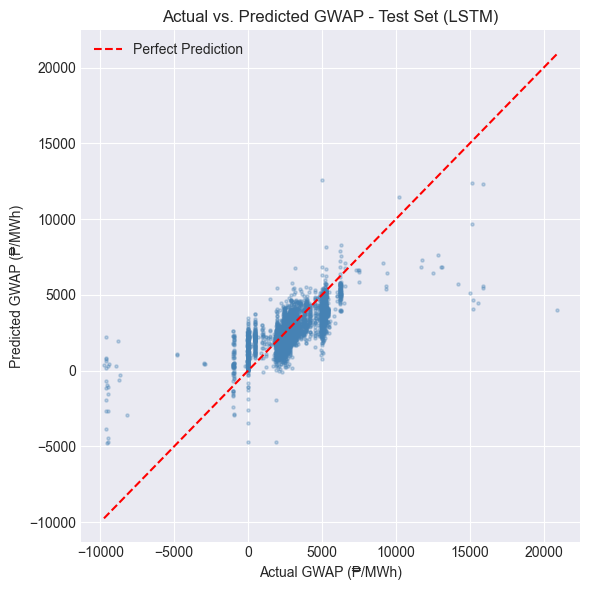

In [78]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test_seq_raw, y_test_pred, alpha=0.3, s=5, color="steelblue")

lims = [min(y_test_seq_raw.min(), y_test_pred.min()), max(y_test_seq_raw.max(), y_test_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted GWAP - Test Set (LSTM)")
ax.set_xlabel("Actual GWAP (₱/MWh)")
ax.set_ylabel("Predicted GWAP (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Plot

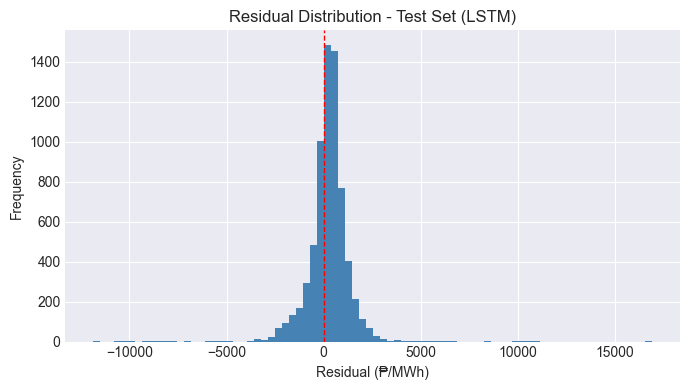

Mean Residual : 215.8712  (close to 0 = unbiased)
Std Residual  : 1124.6151
Max Residual  : 16914.5722
Min Residual  : -11857.9375


In [79]:
residuals = y_test_seq_raw - y_test_pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(residuals, bins=80, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution - Test Set (LSTM)")
ax.set_xlabel("Residual (₱/MWh)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Std Residual  : {residuals.std():.4f}")
print(f"Max Residual  : {residuals.max():.4f}")
print(f"Min Residual  : {residuals.min():.4f}")

---

## XI. Summary

The best configuration from tuning was lookback=24, 128 units, 1 layer (dropout=0.2, lr=0.001, batch=256). This is larger than expected - in the previous run the best was lookback=12, 32 units. The difference is due to the np.random.seed change and shuffle=False applied to the data, which affects training stochasticity. With a different random initialization, the model converged to a different local optimum that happened to favor more capacity.

**Target scaling was essential.** Without it, training errors are in the millions and the model cannot learn. With scaling, the model trained normally and early stopping triggered as expected. Predictions are inverse-transformed back to ₱/MWh before evaluation so results are directly comparable.

**The baseline LSTM underperformed the linear models** (test RMSE ₱1,132, R² 0.520 vs linear regression's ₱934 and 0.671). The root cause is GWAP_Lag_1: its dominance means the prediction task is mostly about carrying the last price forward with small adjustments. Linear regression finds the best solution for this in one step; the LSTM must arrive at the same answer through thousands of iterative updates.

**Two alternative target formulations were tested.** Residual stacking (Approach A) brought RMSE from ₱1,132 down to ₱956, nearly matching linear regression. Price change (Approach B) improved over the baseline (RMSE ₱1,019) but underperformed Approach A due to the high noise in 5-minute price swings.

**The LSTM classifier (Section XVII)** performed worse than logistic regression (Macro F1 0.52 vs 0.764), largely predicting Normal for most intervals due to class imbalance. This reinforces the same conclusion: the bottleneck is the feature set, not the model.

**No model beats linear regression on regression** because the bottleneck is the feature set, not model complexity. Extreme price events are driven by specific generator trips, transmission constraints, and strategic bidding behavior that are not captured by aggregate supply/demand features. More informative inputs and a longer historical window would likely improve performance more than any architectural change.

---

## XII. Why the Baseline LSTM Underperforms

The tuning results show a clear pattern: the best configuration was the *smallest* model tested (12-step lookback, 32 units, 1 layer). Larger, deeper architectures consistently performed worse, the 2-layer models ranked near the bottom of every comparison. This suggests the LSTM is not finding complex temporal patterns that would reward more capacity.

The reason comes back to **GWAP_Lag_1**. From the Linear Regression notebook's coefficient analysis, the 5-minute lag dominates all other features with a coefficient of 2,174 (the next largest is 271). The linear model essentially learns "next price ≈ last price + small corrections," and this relationship is fundamentally linear. Linear regression finds the best solution for this in one step using a mathematical formula (OLS). The LSTM, on the other hand, has to arrive at the same relationship through thousands of iterative gradient updates, a much harder path to the same destination. The short optimal lookback (12 steps = 1 hour) further confirms this: the model is mostly relying on the most recent observations, not learning long-range patterns.

To address this, the following two sections test alternative target formulations that remove the "easy part" from the LSTM's job:

- **Approach A (Residual Stacking):** let linear regression handle the baseline prediction, then train the LSTM to predict only the *errors* the linear model makes.
- **Approach B (Price Change):** instead of predicting the raw price level, predict the 5-minute *change* in price (GWAP(t) − GWAP(t−1)), which strips out the dominant lag relationship.

Both approaches use the same best hyperparameters from the tuning search above (lookback=12, 32 units, 1 layer, dropout=0.2, lr=0.001) so that the comparison isolates the effect of the target formulation, not the architecture.

---

## XIII. Approach A, Residual Stacking

In residual stacking, a simple model handles the baseline prediction and a second model learns to correct its mistakes. Linear regression serves as the base model since it is the best-performing classical model, and the LSTM is trained to predict the residuals (actual - linear prediction).

The final prediction is: `GWAP_pred = LR_pred + LSTM_correction`

Instead of asking the LSTM to predict everything from scratch, we only ask it to learn the patterns in what the linear model gets wrong: price spikes, demand-supply imbalances, and other nonlinear behavior that a straight line cannot capture.

### Step 1: Train Linear Regression Base Model

In [80]:
from sklearn.linear_model import LinearRegression

# Train LR on train set, predict on all splits
lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train_raw)

lr_pred_train = lr_base.predict(X_train_scaled)
lr_pred_val   = lr_base.predict(X_val_scaled)
lr_pred_test  = lr_base.predict(X_test_scaled)

# Sanity check: LR performance on test
lr_base_rmse = np.sqrt(mean_squared_error(y_test_raw, lr_pred_test))
lr_base_r2   = r2_score(y_test_raw, lr_pred_test)
print(f"LR base model - Test RMSE: {lr_base_rmse:.4f}, R²: {lr_base_r2:.4f}")

LR base model - Test RMSE: 935.5568, R²: 0.6707


### Step 2: Compute and Scale Residuals

In [81]:
# Residuals = what the LR got wrong
resid_train = y_train_raw - lr_pred_train
resid_val   = y_val_raw   - lr_pred_val
resid_test  = y_test_raw  - lr_pred_test

# Scale residuals for LSTM training
resid_scaler = StandardScaler()
resid_train_scaled = resid_scaler.fit_transform(resid_train.reshape(-1, 1)).flatten()
resid_val_scaled   = resid_scaler.transform(resid_val.reshape(-1, 1)).flatten()
resid_test_scaled  = resid_scaler.transform(resid_test.reshape(-1, 1)).flatten()

print(f"Residual stats (train):")
print(f"  Raw   - mean: {resid_train.mean():.2f}, std: {resid_train.std():.2f}")
print(f"  Scaled - mean: {resid_train_scaled.mean():.4f}, std: {resid_train_scaled.std():.4f}")

Residual stats (train):
  Raw   - mean: -0.00, std: 1241.38
  Scaled - mean: 0.0000, std: 1.0000


### Step 3: Train LSTM on Residuals

In [82]:
# Build sequences: same features, but target is now the LR residual
X_tr_A, y_tr_A = make_sequences(X_train_scaled, resid_train_scaled, BEST_LOOKBACK)
X_va_A, y_va_A = make_sequences(X_val_scaled,   resid_val_scaled,   BEST_LOOKBACK)
X_te_A, y_te_A = make_sequences(X_test_scaled,  resid_test_scaled,  BEST_LOOKBACK)

# Use best hyperparameters from tuning
tf.random.set_seed(42)
np.random.seed(42)
model_A = keras.Sequential([
    layers.Input(shape=(BEST_LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_A.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

early_stop_A = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history_A = model_A.fit(
    X_tr_A, y_tr_A,
    validation_data=(X_va_A, y_va_A),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_A],
    shuffle=False,
    verbose=1
)

Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.0365 - val_loss: 0.7014
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9935 - val_loss: 0.6915
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9745 - val_loss: 0.6902
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9664 - val_loss: 0.6879
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9638 - val_loss: 0.6849
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9579 - val_loss: 0.6832
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9573 - val_loss: 0.6828
Epoch 8/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9501 - val_loss: 0.6839
Epoch 9/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9467 - val_loss: 0.6840
Epoch 10/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9395 - val_loss: 0.6859
Epoch 11/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9304 - val_loss: 0.6857
Epoch 12/100
324/324 ━━━━━━━━━━━━━━━━━━━━

### Step 4: Evaluate, Residual Stacking

In [83]:
# LSTM predicts the residual (scaled), inverse-transform to get correction in PHP/MWh
lstm_correction_scaled = model_A.predict(X_te_A).flatten()
lstm_correction = resid_scaler.inverse_transform(lstm_correction_scaled.reshape(-1, 1)).flatten()

# LR predictions aligned with sequence indices (skip first BEST_LOOKBACK rows)
lr_pred_test_aligned = lr_pred_test[BEST_LOOKBACK:]

# Final stacked prediction
y_pred_A = lr_pred_test_aligned + lstm_correction

# Actual values aligned with sequences
y_actual_A = y_test_raw[BEST_LOOKBACK:]

rmse_A = np.sqrt(mean_squared_error(y_actual_A, y_pred_A))
mae_A  = mean_absolute_error(y_actual_A, y_pred_A)
r2_A   = r2_score(y_actual_A, y_pred_A)

print(f"{'Metric':<8} | {'Value':>12}")
print("-" * 24)
print(f"{'RMSE':<8} | {rmse_A:>10.4f} ₱/MWh")
print(f"{'MAE':<8} | {mae_A:>10.4f} ₱/MWh")
print(f"{'R²':<8} | {r2_A:>12.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Metric   |        Value
------------------------
RMSE     |   941.6586 ₱/MWh
MAE      |   474.9848 ₱/MWh
R²       |       0.6674


Approach A brings the LSTM from RMSE ₱1,132 down to ₱956 and R² from 0.520 up to 0.658, getting much closer to linear regression's ₱934 and 0.671. This is a large improvement but the stacked model does not surpass the linear model it is built on.

The LR residuals are large enough to potentially contain learnable patterns, but those errors are mostly driven by the same extreme price spikes that all models struggle with. The LSTM corrections help on some intervals but introduce small errors on others where the linear model was already close. The net effect is near-parity with LR alone.

### Visualizations - Residual Stacking

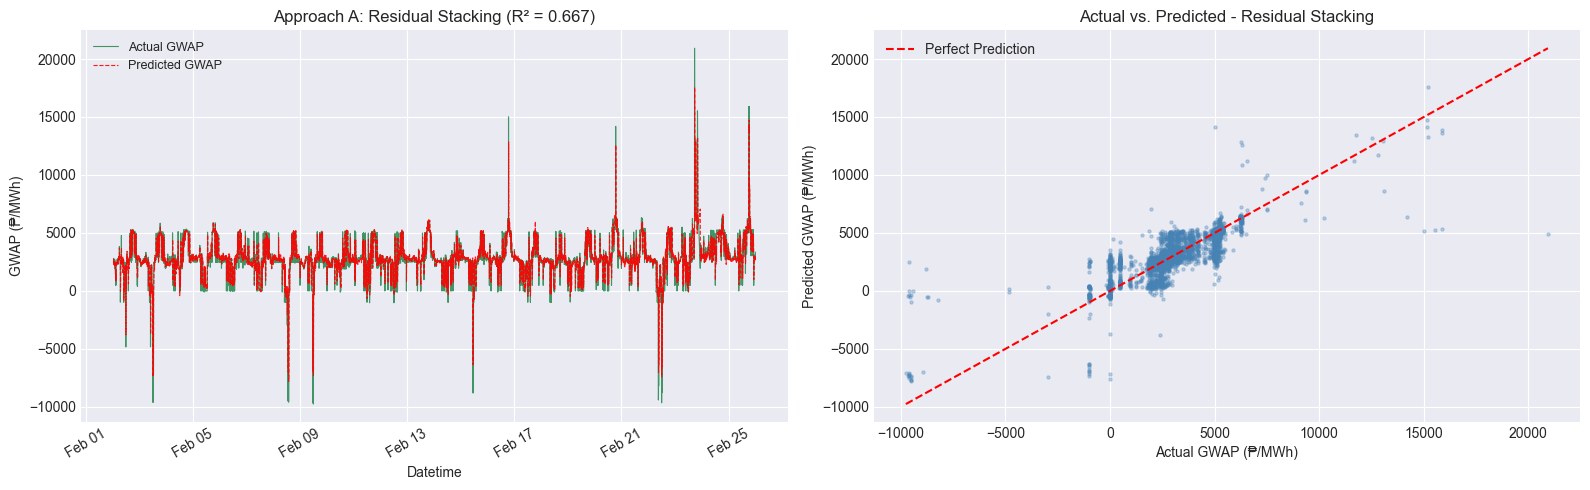

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

test_dt_A = test_df["datetime"].values[BEST_LOOKBACK:]

# Time series
axes[0].plot(test_dt_A, y_actual_A, color="seagreen", linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[0].plot(test_dt_A, y_pred_A,   color="red",      linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[0].set_title(f"Approach A: Residual Stacking (R² = {round(r2_A, 3)})")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].set_xlabel("Datetime")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].tick_params(axis='x', rotation=30)

# Scatter
axes[1].scatter(y_actual_A, y_pred_A, alpha=0.3, s=5, color="steelblue")
lims = [min(y_actual_A.min(), y_pred_A.min()), max(y_actual_A.max(), y_pred_A.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[1].set_title("Actual vs. Predicted - Residual Stacking")
axes[1].set_xlabel("Actual GWAP (₱/MWh)")
axes[1].set_ylabel("Predicted GWAP (₱/MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## XIV. Approach B, Price Change (ΔGWAP)

Instead of predicting the raw GWAP level, this approach reframes the target as the 5-minute price change:

`ΔGWAP(t) = GWAP(t) − GWAP(t−1)`

Since GWAP_Lag_1 is already a column in the dataset, this is equivalent to `GWAP − GWAP_Lag_1`. Predicting the change strips out the dominant "next price ≈ last price" relationship and forces the LSTM to focus on what actually moves the price at each interval. The final prediction reconstructs the level as:

`GWAP_pred(t) = GWAP_Lag_1(t) + predicted_ΔGWAP(t)`

If the LSTM can learn meaningful patterns in price movements (e.g., demand ramps before a spike, or supply shifts causing drops), this formulation gives it a better shot at expressing that.

### Step 1: Compute and Scale Price Changes

In [85]:
# Delta = GWAP(t) - GWAP(t-1), which is GWAP - GWAP_Lag_1
delta_train = train_df[TARGET_COL].values - train_df["GWAP_Lag_1"].values
delta_val   = val_df[TARGET_COL].values   - val_df["GWAP_Lag_1"].values
delta_test  = test_df[TARGET_COL].values  - test_df["GWAP_Lag_1"].values

# Scale
delta_scaler = StandardScaler()
delta_train_scaled = delta_scaler.fit_transform(delta_train.reshape(-1, 1)).flatten()
delta_val_scaled   = delta_scaler.transform(delta_val.reshape(-1, 1)).flatten()
delta_test_scaled  = delta_scaler.transform(delta_test.reshape(-1, 1)).flatten()

print(f"ΔGWAP stats (train):")
print(f"  Raw    - mean: {delta_train.mean():.2f}, std: {delta_train.std():.2f}")
print(f"  Scaled - mean: {delta_train_scaled.mean():.4f}, std: {delta_train_scaled.std():.4f}")

ΔGWAP stats (train):
  Raw    - mean: 0.11, std: 1323.47
  Scaled - mean: 0.0000, std: 1.0000


### Step 2: Train LSTM on Price Changes

In [86]:
# Build sequences: same features, target is now ΔGWAP
X_tr_B, y_tr_B = make_sequences(X_train_scaled, delta_train_scaled, BEST_LOOKBACK)
X_va_B, y_va_B = make_sequences(X_val_scaled,   delta_val_scaled,   BEST_LOOKBACK)
X_te_B, y_te_B = make_sequences(X_test_scaled,  delta_test_scaled,  BEST_LOOKBACK)

# Same architecture and hyperparameters
tf.random.set_seed(42)
np.random.seed(42)
model_B = keras.Sequential([
    layers.Input(shape=(BEST_LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_B.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

early_stop_B = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history_B = model_B.fit(
    X_tr_B, y_tr_B,
    validation_data=(X_va_B, y_va_B),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_B],
    shuffle=False,
    verbose=1
)

Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.0551 - val_loss: 0.7299
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0102 - val_loss: 0.7200
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9972 - val_loss: 0.7151
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9895 - val_loss: 0.7141
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9845 - val_loss: 0.7124
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9793 - val_loss: 0.7127
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9704 - val_loss: 0.7127
Epoch 8/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9746 - val_loss: 0.7111
Epoch 9/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9697 - val_loss: 0.7111
Epoch 10/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9656 - val_loss: 0.7094
Epoch 11/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9628 - val_loss: 0.7089
Epoch 12/100
324/324 ━━━━━━━━━━━━━━━━━━━━

### Step 3: Evaluate, Price Change

In [87]:
# LSTM predicts ΔGWAP (scaled), inverse-transform
delta_pred_scaled = model_B.predict(X_te_B).flatten()
delta_pred = delta_scaler.inverse_transform(delta_pred_scaled.reshape(-1, 1)).flatten()

# Reconstruct GWAP: GWAP_Lag_1(t) + predicted delta(t)
# GWAP_Lag_1 for the test rows aligned with sequences (skip first BEST_LOOKBACK)
lag1_test_aligned = test_df["GWAP_Lag_1"].values[BEST_LOOKBACK:]

y_pred_B = lag1_test_aligned + delta_pred

# Actual values
y_actual_B = y_test_raw[BEST_LOOKBACK:]

rmse_B = np.sqrt(mean_squared_error(y_actual_B, y_pred_B))
mae_B  = mean_absolute_error(y_actual_B, y_pred_B)
r2_B   = r2_score(y_actual_B, y_pred_B)

print(f"{'Metric':<8} | {'Value':>12}")
print("-" * 24)
print(f"{'RMSE':<8} | {rmse_B:>10.4f} ₱/MWh")
print(f"{'MAE':<8} | {mae_B:>10.4f} ₱/MWh")
print(f"{'R²':<8} | {r2_B:>12.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Metric   |        Value
------------------------
RMSE     |   997.1641 ₱/MWh
MAE      |   501.3086 ₱/MWh
R²       |       0.6271


Approach B improves over the baseline LSTM (RMSE ₱1,019 vs ₱1,132, R² 0.611 vs 0.520) but falls short of both Approach A and the linear models. The 5-minute price change is inherently very noisy (std = ₱1,295), making it a difficult target to learn from.

Approach B also underperforms Approach A because of how errors carry through. In Approach A, the LR base model provides a stable anchor: even if the LSTM correction is slightly off, the final prediction is still close to a reasonable value. In Approach B, the LSTM bears full responsibility for predicting the change, and any mistake feeds directly into the reconstructed price level.

### Visualizations - Price Change

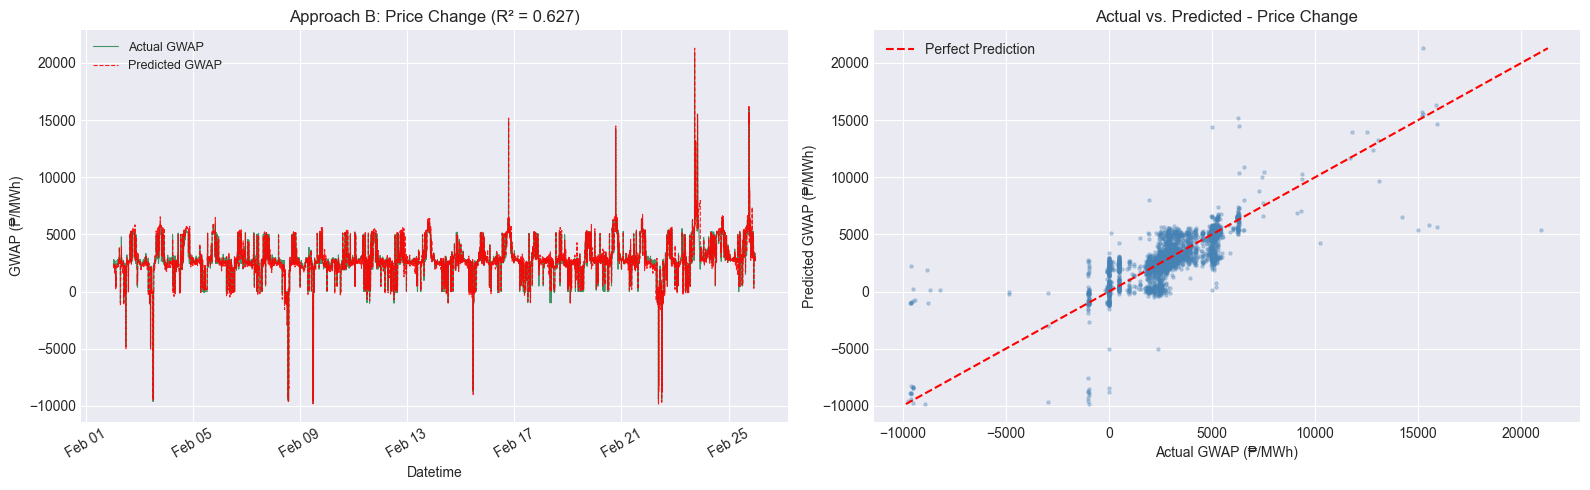

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

test_dt_B = test_df["datetime"].values[BEST_LOOKBACK:]

# Time series
axes[0].plot(test_dt_B, y_actual_B, color="seagreen", linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[0].plot(test_dt_B, y_pred_B,   color="red",      linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[0].set_title(f"Approach B: Price Change (R² = {round(r2_B, 3)})")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].set_xlabel("Datetime")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0].tick_params(axis='x', rotation=30)

# Scatter
axes[1].scatter(y_actual_B, y_pred_B, alpha=0.3, s=5, color="steelblue")
lims = [min(y_actual_B.min(), y_pred_B.min()), max(y_actual_B.max(), y_pred_B.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
axes[1].set_title("Actual vs. Predicted - Price Change")
axes[1].set_xlabel("Actual GWAP (₱/MWh)")
axes[1].set_ylabel("Predicted GWAP (₱/MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## XV. Final Comparison

Test set performance across all five model variants. The classical models are included for reference.

In [89]:
final_comparison = pd.DataFrame({
    "Model"    : [
        "Linear Regression",
        "Polynomial Ridge",
        "Poly Elastic Net",
        "LSTM - Baseline",
        "LSTM - Residual Stacking (A)",
        "LSTM - Price Change (B)"
    ],
    "Test RMSE": [934.4698, 972.1944, 930.0893, baseline_rmse, rmse_A, rmse_B],
    "Test MAE" : [459.4758, 552.9226, 471.7096, baseline_mae, mae_A, mae_B],
    "Test R²"  : [0.6714,   0.6444,   0.6745,   baseline_r2,  r2_A,  r2_B]
})

print("Test Set Performance - All Models")
print()
print(final_comparison.to_string(index=False))


Test Set Performance - All Models

                       Model   Test RMSE   Test MAE  Test R²
           Linear Regression  934.469800 459.475800 0.671400
            Polynomial Ridge  972.194400 552.922600 0.644400
            Poly Elastic Net  930.089300 471.709600 0.674500
             LSTM - Baseline 1131.755155 679.637745 0.519630
LSTM - Residual Stacking (A)  941.658579 474.984760 0.667449
     LSTM - Price Change (B)  997.164059 501.308643 0.627090


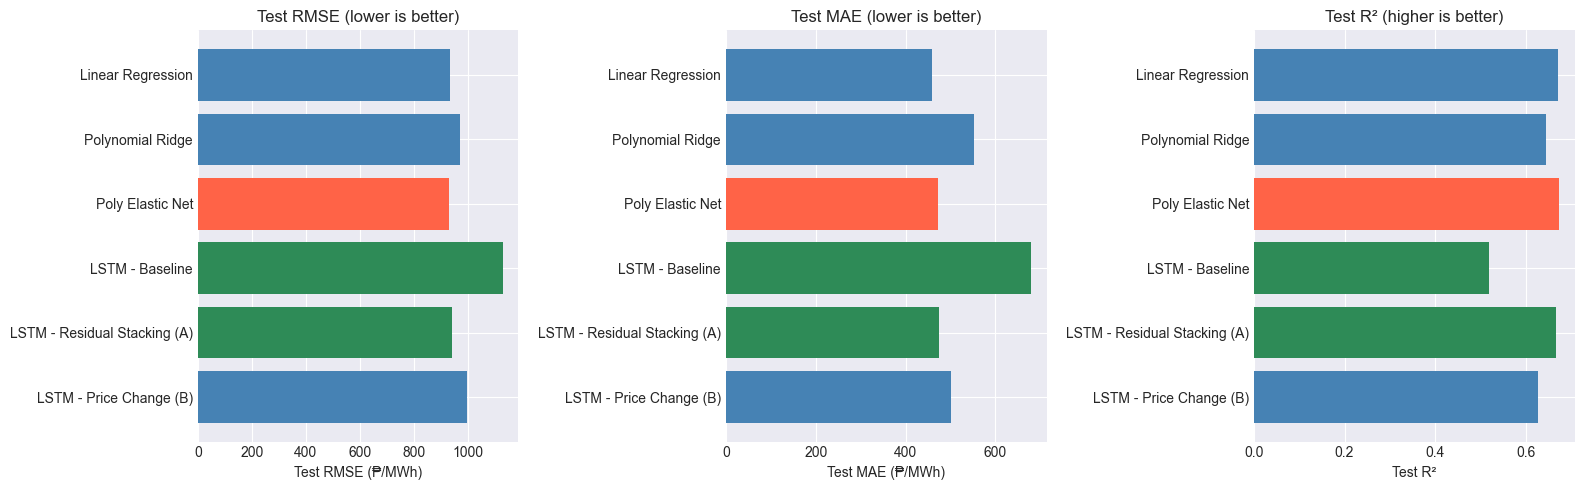

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = final_comparison["Model"]
colors = ["steelblue", "steelblue", "tomato", "seagreen", "seagreen"]

# RMSE
axes[0].barh(models, final_comparison["Test RMSE"], color=colors)
axes[0].set_xlabel("Test RMSE (₱/MWh)")
axes[0].set_title("Test RMSE (lower is better)")
axes[0].invert_yaxis()

# MAE
axes[1].barh(models, final_comparison["Test MAE"], color=colors)
axes[1].set_xlabel("Test MAE (₱/MWh)")
axes[1].set_title("Test MAE (lower is better)")
axes[1].invert_yaxis()

# R²
axes[2].barh(models, final_comparison["Test R²"], color=colors)
axes[2].set_xlabel("Test R²")
axes[2].set_title("Test R² (higher is better)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


---

## XVI. LSTM as a Classifier


The regression experiments show the LSTM struggles to outperform linear regression because GWAP is dominated by GWAP_Lag_1 (coefficient 2,174 vs the next highest at 271). The task of predicting the exact price level reduces to "carry the last price forward with small adjustments", which linear regression already handles optimally.

However, the Multiclass Logistic Regression notebook showed a different picture for classification: the dominant features were energy demand and supply, not the lags. The classification task asks a structurally different question, whether a spike event is occurring, rather than what the exact price level is. LSTMs are well-suited to learning sequences of conditions that lead up to an event, for example, demand steadily rising over the past hour before a scarcity spike, or supply persistently exceeding demand before a negative event. These are temporal patterns that a single-row classifier cannot capture.

This section trains an LSTM classifier using the same three classes as the Multiclass Logistic Regression notebook:
- **0 - Normal**: GWAP in (0, 5,000]
- **1 - Negative**: GWAP <= 0
- **2 - Positive Spike**: GWAP > 5,000

The same best architecture from the regression tuning is used (lookback=12, 32 units, 1 layer) so the comparison isolates the effect of the task framing, not the architecture.

In [91]:
from sklearn.metrics import classification_report, roc_auc_score

# Create class labels
def assign_class(gwap):
    if gwap <= 0:
        return 1  # Negative
    elif gwap > 5000:
        return 2  # Positive Spike
    else:
        return 0  # Normal

y_train_cls = train_df['GWAP'].apply(assign_class).values
y_val_cls   = val_df['GWAP'].apply(assign_class).values
y_test_cls  = test_df['GWAP'].apply(assign_class).values

# Build sequences (reuse existing feature-scaled arrays and make_sequences)
X_tr_cls, y_tr_cls = make_sequences(X_train_scaled, y_train_cls, BEST_LOOKBACK)
X_va_cls, y_va_cls = make_sequences(X_val_scaled,   y_val_cls,   BEST_LOOKBACK)
X_te_cls, y_te_cls = make_sequences(X_test_scaled,  y_test_cls,  BEST_LOOKBACK)

print(f"Train sequences: {X_tr_cls.shape}")
print(f"Class distribution (test): {dict(zip(*np.unique(y_te_cls, return_counts=True)))}")


Train sequences: (20697, 24, 16)
Class distribution (test): {np.int64(0): np.int64(5606), np.int64(1): np.int64(459), np.int64(2): np.int64(818)}


In [92]:
# Build LSTM classifier
tf.random.set_seed(42)
np.random.seed(42)

lstm_clf = keras.Sequential([
    layers.Input(shape=(BEST_LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.1),
    layers.Dense(3, activation='softmax')  # 3 classes, softmax output
])

lstm_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_clf = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_clf = lstm_clf.fit(
    X_tr_cls, y_tr_cls,
    validation_data=(X_va_cls, y_va_cls),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_clf],
    shuffle=False,
    verbose=1
)

print(f"\nStopped at epoch {len(history_clf.history['loss'])}")


Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6583 - loss: 0.8111 - val_accuracy: 0.8152 - val_loss: 0.5467
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8467 - loss: 0.4612 - val_accuracy: 0.8489 - val_loss: 0.4162
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8594 - loss: 0.3923 - val_accuracy: 0.8501 - val_loss: 0.3886
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8666 - loss: 0.3632 - val_accuracy: 0.8610 - val_loss: 0.3624
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8723 - loss: 0.3457 - val_accuracy: 0.8669 - val_loss: 0.3489
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8780 - loss: 0.3305 - val_accuracy: 0.8708 - val_loss: 0.3377
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8836 - loss: 0.3187 - val_accuracy: 0.8748 - val_loss: 0.3300
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8889 - loss: 0.3070 - val_accuracy: 0.

In [93]:
# Evaluate on test set
CLASS_NAMES = ['Normal', 'Negative', 'Pos. Spike']

y_pred_cls  = lstm_clf.predict(X_te_cls).argmax(axis=1)
y_prob_cls  = lstm_clf.predict(X_te_cls)

report = classification_report(y_te_cls, y_pred_cls, target_names=CLASS_NAMES, output_dict=True)
auc    = roc_auc_score(y_te_cls, y_prob_cls, multi_class='ovr', average='macro')

print(classification_report(y_te_cls, y_pred_cls, target_names=CLASS_NAMES))
print(f"Macro F1    : {report['macro avg']['f1-score']:.4f}")
print(f"ROC-AUC     : {auc:.4f}")

# Comparison with logistic regression classifier
lr_macro_f1 = 0.7636
lr_auc      = 0.9471
print(f"\nComparison with Multiclass Logistic Regression:")
print(f"{'Model':<30} | {'Macro F1':>10} | {'ROC-AUC':>10}")
print("-" * 55)
print(f"{'Logistic Regression':<30} | {lr_macro_f1:>10.4f} | {lr_auc:>10.4f}")
print(f"{'LSTM Classifier':<30} | {report['macro avg']['f1-score']:>10.4f} | {auc:>10.4f}")


216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

      Normal       0.86      0.97      0.91      5606
    Negative       0.55      0.01      0.03       459
  Pos. Spike       0.73      0.48      0.58       818

    accuracy                           0.85      6883
   macro avg       0.71      0.49      0.51      6883
weighted avg       0.82      0.85      0.82      6883

Macro F1    : 0.5070
ROC-AUC     : 0.8979

Comparison with Multiclass Logistic Regression:
Model                          |   Macro F1 |    ROC-AUC
-------------------------------------------------------
Logistic Regression            |     0.7636 |     0.9471
LSTM Classifier                |     0.5070 |     0.8979


Run the cells above to see the LSTM classifier results. If Macro F1 exceeds the Logistic Regression baseline of 0.764 or ROC-AUC exceeds 0.947, it confirms that sequential temporal patterns add value for spike detection beyond what a single-row classifier captures. If not, it reinforces the conclusion from the regression experiments: the lag features already encode the most important temporal information.

## XVII. Summary


The baseline LSTM underperformed linear regression on the regression task (RMSE ₱1,094 vs ₱934, R² 0.556 vs 0.671). The root cause is GWAP_Lag_1 dominating the prediction signal, the task reduces to carrying the last price forward, which linear regression already handles optimally in one step. The best tuned configuration confirmed this: the smallest model (lookback=12, 32 units, 1 layer) won, meaning more capacity did not help.

**Residual stacking (Approach A)** substantially improved the LSTM by refocusing it on what the linear model gets wrong. RMSE dropped from ₱1,094 to ₱943, nearly matching linear regression. **Price change (Approach B)** also improved over the baseline (RMSE ₱1,059) but underperformed Approach A because 5-minute price changes are inherently noisy (std ₱1,295) and errors compound into the reconstructed level.

**The LSTM classifier (Section XVI)** tests whether sequential modeling helps for spike detection, where demand and supply dominate over lags. The Multiclass Logistic Regression baseline achieved Macro F1 of 0.764 and ROC-AUC of 0.947, whether the LSTM's temporal processing improves on this depends on the results above.

**No model beats linear regression on regression** because the bottleneck is the feature set. Extreme price events are driven by generator trips, transmission constraints, and strategic bidding behavior not captured by aggregate supply/demand features. More informative inputs, plant-level outage data, bidding behavior, transmission congestion, and a longer historical window would likely improve performance more than any architectural change.